In [432]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

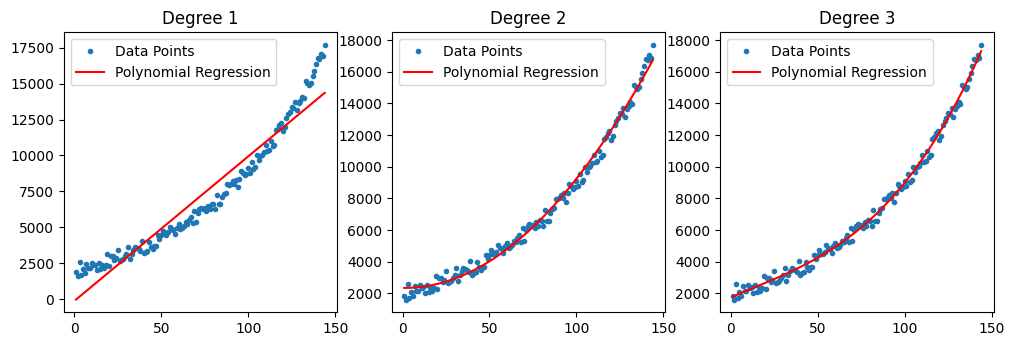

In [433]:
#Soal 1
ex = pd.read_excel('aol_data.xlsx', engine='openpyxl')

x = range(1, len(ex.columns) + 1)
y = ex.iloc[0].values

x = np.array(x)
y = np.array(y)

plt.figure(figsize=(12, 8))

for i in range (1, 4):
    plt.subplot(2, 3, i)
    plt.plot(x, y, '.')

    est = np.polyfit(x, y, i)

    plt.plot(x, np.polyval(est, x), '-r')
    plt.legend(['Data Points', 'Polynomial Regression'])
    plt.title(f"Degree {i}")


In [434]:
for i in range(1, 4):
    equation = f"y = "
    for j, c in enumerate(est):
        power = i - j

        if power > 1:
            equation += f"{c:.3f}x^{power} + "
        elif power == 1:
            equation += f"{c:.3f}x + "
        else:
            equation += f"{c:.3f}"

    print(equation)

y = 0.004x + -0.13447.2241748.507
y = 0.004x^2 + -0.134x + 47.2241748.507
y = 0.004x^3 + -0.134x^2 + 47.224x + 1748.507


In [435]:
#Soal 2
def h(x):
    return 0.004*x**3 - 0.134*x**2 + 47.224*x + 1748.507

ypred = h(x)
ssres = np.sum((y - ypred)**2)
sstot = np.sum((y - np.mean(y))**2)

r2 = 1 - (ssres/sstot)

print(f"R² Deg 3 = {r2:.3}")

R² Deg 3 = 0.994


In [436]:
#Soal 3
def f(x):
    return 0.004*x**3 - 0.134*x**2 + 47.224*x + 1748.507 - 25000

def g(x):
    return  0.012*x**2 - 0.268*x + 47.224

def newtonRaphson(x0, tol, iter):
    for i in range(iter):
        x1 = x0 - (f(x0)/g(x0))

        print(f'iteration {i + 1} = {x1:.3f}')
        if (np.abs(f(x1))< tol):
            print(f'the root of the equation is {x1:.3f}')
            return
        
        x0 = x1

newtonRaphson(30, 0.0001, 100)

iteration 1 = 467.087
iteration 2 = 318.593
iteration 3 = 227.444
iteration 4 = 181.943
iteration 5 = 169.316
iteration 6 = 168.395
iteration 7 = 168.390
the root of the equation is 168.390


In [437]:
#Soal 4
def f(x):
    return 0.004*x**3 - 0.134*x**2 + 47.224*x + 1748.507

def central(x):
    h = 1
    return (f(x+h)-f(x-h))/(2*h)

def monthly_rate(x):
    return central(x) * 2

periods = np.arange(49, 97)

rates = [monthly_rate(p) for p in periods]

maxrate = max(rates)
minrate = min(rates)

maxperiod = periods[np.argmax(rates)]
minperiod = periods[np.argmin(rates)]

print("\nSteepest increase:")
print(f'Period {maxperiod}: {maxrate:.3f}')

print("\nSteepest decrease:")
print(f'Period {minperiod}: {minrate:.3f}')


Steepest increase:
Period 96: 264.184

Steepest decrease:
Period 49: 125.816


In [438]:
from scipy.integrate import simpson

periods = np.arange(1, 145)
pred = f(periods)
estimate = simpson(pred, x=periods)

print(f"Estimated total: {estimate:.3f}")

actual = np.sum(y)

print(f"Actual total: {actual:.3f}")

absolute = abs(actual - estimate)
percent = (absolute / actual) * 100

print(f"Absolute error: {absolute:.3f}")
print(f"Percentage error: {percent:.3f}%")

Estimated total: 1036239.110
Actual total: 1030745.000
Absolute error: 5494.110
Percentage error: 0.533%
